# Regressão logística do zero

**Tema:** Aprendizado Supervisionado › Regressão Logística

Este notebook implementa regressão logística via gradiente descendente
(tema 2), derivando a função de perda a partir de máxima verossimilhança
(tema 1) — e confirma que bate com `sklearn.LogisticRegression`. Depois
reproduz, de propósito, um caso de separação perfeita para mostrar o que
acontece quando o ajuste diverge.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
np.set_printoptions(precision=4, suppress=True)
print("pronto")

pronto


## 1. Sigmoide e logit: confirmando que são inversas uma da outra

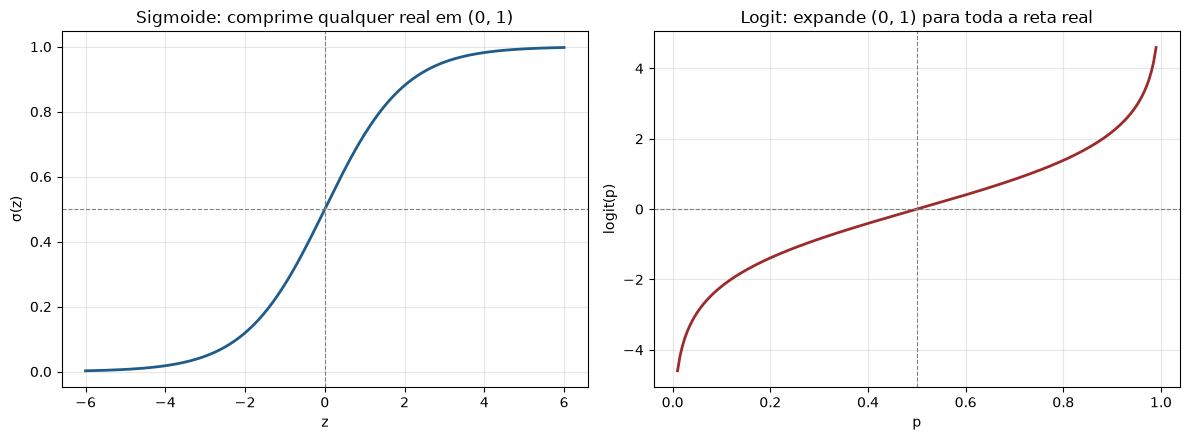

sigmoide(logit(0.7)) = 0.700000   (deveria ser 0.7)


In [2]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))


def logit(p):
    return np.log(p / (1 - p))


z_teste = np.linspace(-6, 6, 200)
p_teste = sigmoide(z_teste)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(z_teste, p_teste, color=AZUL, lw=2)
axes[0].axhline(0.5, color="gray", ls="--", lw=0.8)
axes[0].axvline(0, color="gray", ls="--", lw=0.8)
axes[0].set_xlabel("z"); axes[0].set_ylabel("σ(z)")
axes[0].set_title("Sigmoide: comprime qualquer real em (0, 1)")

p_grid = np.linspace(0.01, 0.99, 200)
axes[1].plot(p_grid, logit(p_grid), color=VERMELHO, lw=2)
axes[1].axhline(0, color="gray", ls="--", lw=0.8)
axes[1].axvline(0.5, color="gray", ls="--", lw=0.8)
axes[1].set_xlabel("p"); axes[1].set_ylabel("logit(p)")
axes[1].set_title("Logit: expande (0, 1) para toda a reta real")
plt.tight_layout(); plt.show()

print(f"sigmoide(logit(0.7)) = {sigmoide(logit(0.7)):.6f}   (deveria ser 0.7)")

## 2. A perda de entropia cruzada, derivada de máxima verossimilhança

In [3]:
def entropia_cruzada(beta, X, y):
    z = X @ beta
    p = sigmoide(z)
    eps = 1e-12  # evita log(0)
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))


def gradiente_entropia_cruzada(beta, X, y):
    p = sigmoide(X @ beta)
    return X.T @ (p - y) / len(y)

## 3. Ajustando via gradiente descendente e comparando com sklearn

                                                   coeficientes
-----------------------------------------------------------------
  verdadeiro                              [-0.5  2.  -1.5  1. ]
GD (do zero)                  [-0.4697  1.9418 -1.5379  0.8205]
     sklearn                  [-0.4697  1.942  -1.5383  0.8209]


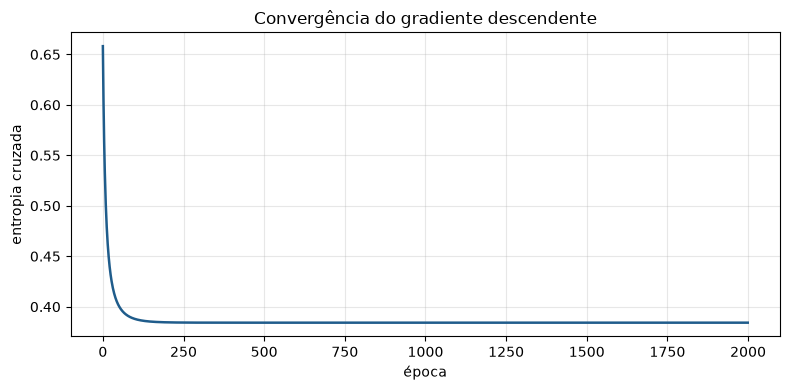

In [4]:
n, p = 800, 3
X_bruto = rng.normal(0, 1, (n, p))
X = np.column_stack([np.ones(n), X_bruto])
beta_real = np.array([-0.5, 2.0, -1.5, 1.0])
prob_real = sigmoide(X @ beta_real)
y = (rng.random(n) < prob_real).astype(float)


def gd_logistico(X, y, eta, n_epocas):
    beta = np.zeros(X.shape[1])
    historico_perda = []
    for _ in range(n_epocas):
        grad = gradiente_entropia_cruzada(beta, X, y)
        beta = beta - eta * grad
        historico_perda.append(entropia_cruzada(beta, X, y))
    return beta, historico_perda


beta_gd, historico = gd_logistico(X, y, eta=0.3, n_epocas=2000)
modelo_sklearn = LogisticRegression(fit_intercept=False, C=np.inf).fit(X, y)

print(f"{'':>12s} {'coeficientes':>50s}")
print("-" * 65)
print(f"{'verdadeiro':>12s} {np.array2string(beta_real, precision=4):>50s}")
print(f"{'GD (do zero)':>12s} {np.array2string(beta_gd, precision=4):>50s}")
print(f"{'sklearn':>12s} {np.array2string(modelo_sklearn.coef_[0], precision=4):>50s}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(historico, color=AZUL, lw=1.8)
ax.set_xlabel("época"); ax.set_ylabel("entropia cruzada")
ax.set_title("Convergência do gradiente descendente")
plt.tight_layout(); plt.show()

## 4. Visualizando a fronteira de decisão: um hiperplano

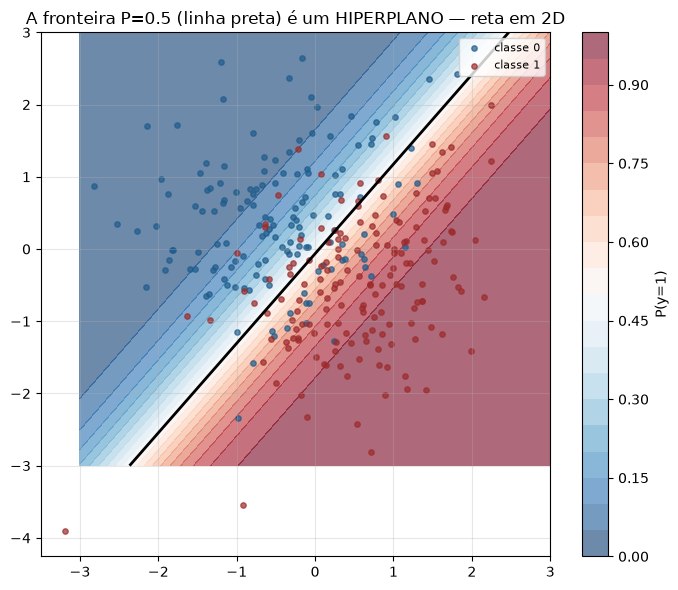

In [5]:
X2d = rng.normal(0, 1, (300, 2))
beta_2d = np.array([0.0, 2.5, -1.8])
z_2d = beta_2d[0] + X2d @ beta_2d[1:]
prob_2d = sigmoide(z_2d)
y_2d = (rng.random(300) < prob_2d).astype(int)

X2d_com_intercepto = np.column_stack([np.ones(300), X2d])
beta_2d_ajustado, _ = gd_logistico(X2d_com_intercepto, y_2d.astype(float), eta=0.5, n_epocas=3000)

xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grade = np.column_stack([np.ones(xx.size), xx.ravel(), yy.ravel()])
prob_grade = sigmoide(grade @ beta_2d_ajustado).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
contorno = ax.contourf(xx, yy, prob_grade, levels=20, cmap="RdBu_r", alpha=0.6)
ax.contour(xx, yy, prob_grade, levels=[0.5], colors="black", linewidths=2)
ax.scatter(X2d[y_2d == 0, 0], X2d[y_2d == 0, 1], s=15, color=AZUL, label="classe 0", alpha=0.7)
ax.scatter(X2d[y_2d == 1, 0], X2d[y_2d == 1, 1], s=15, color=VERMELHO, label="classe 1", alpha=0.7)
plt.colorbar(contorno, label="P(y=1)")
ax.set_title("A fronteira P=0.5 (linha preta) é um HIPERPLANO — reta em 2D")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Separação perfeita: quando o ajuste diverge

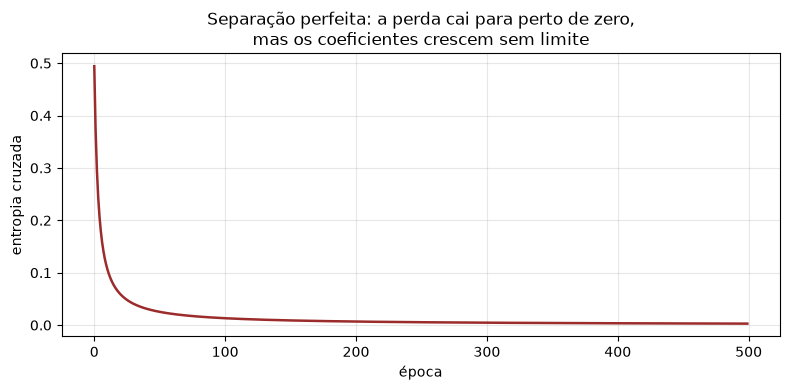

coeficientes após 500 épocas: [0.0203 2.097 ]
Esses números continuariam crescendo indefinidamente com mais épocas —
não há máximo finito para a verossimilhança quando as classes são
perfeitamente separáveis por essa única feature.

com regularização L2 (sklearn, C=1.0): coeficiente = 1.7712   (finito, por construção)


In [6]:
x_separavel = np.concatenate([rng.normal(-3, 0.5, 50), rng.normal(3, 0.5, 50)])
y_separavel = np.concatenate([np.zeros(50), np.ones(50)])
X_separavel = np.column_stack([np.ones(100), x_separavel])

_, historico_divergente = gd_logistico(X_separavel, y_separavel, eta=0.1, n_epocas=500)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(historico_divergente, color=VERMELHO, lw=1.8)
ax.set_xlabel("época"); ax.set_ylabel("entropia cruzada")
ax.set_title("Separação perfeita: a perda cai para perto de zero,\n"
             "mas os coeficientes crescem sem limite")
plt.tight_layout(); plt.show()

beta_divergente, _ = gd_logistico(X_separavel, y_separavel, eta=0.1, n_epocas=500)
print(f"coeficientes após 500 épocas: {beta_divergente}")
print("Esses números continuariam crescendo indefinidamente com mais épocas —")
print("não há máximo finito para a verossimilhança quando as classes são")
print("perfeitamente separáveis por essa única feature.")

modelo_regularizado = LogisticRegression(C=1.0).fit(
    x_separavel.reshape(-1, 1), y_separavel)
print(f"\ncom regularização L2 (sklearn, C=1.0): coeficiente = "
      f"{modelo_regularizado.coef_[0][0]:.4f}   (finito, por construção)")

## O que levar deste notebook

- Sigmoide e logit são inversas: uma comprime a reta real em $(0,1)$, a
  outra expande $(0,1)$ de volta para a reta real.
- A entropia cruzada não é uma escolha arbitrária de função de perda — é a
  log-verossimilhança negativa de uma Bernoulli, o mesmo princípio de
  máxima verossimilhança do tema 1.
- A fronteira de decisão de $P=0{,}5$ é sempre um hiperplano — regressão
  logística é, geometricamente, um classificador linear.
- Separação perfeita faz os coeficientes divergirem sem limite;
  regularização (módulo 2) resolve isso ao custo de um pouco de viés.

→ Próximo: **Interpretação e odds ratio**, o vocabulário certo para
comunicar coeficientes de um modelo logístico.